# Intro to Computational Math Capstone Project
### Group number: 

### Members:
- My Pham (UFID: 12494292)
- 
- 

# 1. Load the Dataset and Packages

## a. Load the Packages needed

In [18]:
from pathlib import Path
import pandas as pd
import os, sys
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

## b. Load the Dataset

In [16]:
print("Notebook cwd:", os.getcwd())
name = "AmesHousing.csv"
# Common candidate locations (local, parent, data folders, home)
candidates = [
    Path.cwd() / name,
    Path.cwd().parent / name,
    Path.cwd() / "data" / name,
    Path.cwd().parent / "data" / name,
    Path.cwd().parent.parent / name,
    Path.home() / name,
]

found = None
tried = []
for p in candidates:
    tried.append(str(p))
    if p.exists():
        found = p
        break

# If still not found, do a limited rglob search from cwd and its parents (depth-limited)
if not found:
    for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        try:
            for p in root.rglob(name):
                tried.append(str(p))
                found = p
                break
            if found:
                break
        except Exception:
            pass

if not found:
    msg = "AmesHousing.csv not found. Paths searched:\n" + "\n".join(tried)
    raise FileNotFoundError(msg)

csv_path = found
print("Using file:", csv_path)
df = pd.read_csv(csv_path)
print("Initial shape:", df.shape)
df.head()

Notebook cwd: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\code
Using file: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing.csv
Initial shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# 2. Data Cleaning

In [5]:
# 1. Drop exact duplicate rows
before_shape = df.shape
df = df.drop_duplicates()
print(f"Dropped duplicates: {before_shape[0] - df.shape[0]} rows")

# 2. Drop columns with more than 50% missing values
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.5].index.tolist()
if cols_to_drop:
    print("Dropping columns with >50% missing:", cols_to_drop)
    df = df.drop(columns=cols_to_drop)
else:
    print("No columns with >50% missing to drop")

# 3. Fill numeric NaNs with median, categorical NaNs with mode (or 'Missing')
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

for c in num_cols:
    if df[c].isnull().any():
        median = df[c].median()
        df[c] = df[c].fillna(median)

for c in cat_cols:
    if df[c].isnull().any():
        mode = df[c].mode()
        fill = mode[0] if not mode.empty else 'Missing'
        df[c] = df[c].fillna(fill)
    # strip whitespace for object columns
    if df[c].dtype == 'object':
        df[c] = df[c].str.strip()

# 4. Convert object columns with reasonably small cardinality to 'category' dtype
for c in cat_cols:
    try:
        if df[c].nunique(dropna=False) < 200:
            df[c] = df[c].astype('category')
    except Exception:
        pass

print("After cleaning shape:", df.shape)
print("Total remaining missing values:", df.isnull().sum().sum())
df.head()

Dropped duplicates: 0 rows
Dropping columns with >50% missing: ['Alley', 'Mas Vnr Type', 'Pool QC', 'Fence', 'Misc Feature']
After cleaning shape: (2930, 77)
Total remaining missing values: 0


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900


Save the cleaned Dataframe to a new CSV file named 'AmesHousing_cleaned.csv'

In [6]:
output_path = Path.cwd().parent / "data" / "AmesHousing_cleaned.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.2f} KB")

Cleaned dataset saved to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing_cleaned.csv
File size: 945.25 KB


# 3. Create modeling dataset using selected features

In [13]:
features = ['Gr Liv Area', 'Overall Qual', 'Year Built']
target = 'SalePrice'

cols = features + [target]

# If df isn't in memory (kernel restart or out-of-order run), try to load cleaned CSV
if 'df' not in globals():
    cleaned_path = Path.cwd().parent / "data" / "AmesHousing_cleaned.csv"
    if cleaned_path.exists():
        print(f"'df' not found in memory — loading cleaned CSV from {cleaned_path}")
        df = pd.read_csv(cleaned_path)
    else:
        raise NameError("'df' not defined and cleaned CSV not found. Run the data-loading/cleaning cells or create 'data/AmesHousing_cleaned.csv'.")

# Verify required columns exist in df
missing = [c for c in cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns for modeling dataset: {missing}")

model_df = df[cols].copy()
# Drop rows with missing values in these columns (should be none after cleaning)
before = model_df.shape[0]
model_df = model_df.dropna()
dropped = before - model_df.shape[0]
print(f"Modeling dataset shape: {model_df.shape} (dropped {dropped} rows)")
# Save modeling dataset
model_path = Path.cwd().parent / 'data' / 'AmesHousing_model.csv'
model_path.parent.mkdir(parents=True, exist_ok=True)
model_df.to_csv(model_path, index=False)
print(f"Saved modeling dataset to: {model_path}")
model_df.head()

Modeling dataset shape: (2930, 4) (dropped 0 rows)
Saved modeling dataset to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing_model.csv


,Gr Liv Area,Overall Qual,Year Built,SalePrice
0,1656,6,1960,215000
1,896,5,1961,105000
2,1329,6,1958,172000
3,2110,7,1968,244000
4,1629,5,1997,189900


# 4. Mathematical Work

## a. Compute correlation

Correlation matrix:
               Gr Liv Area  Overall Qual  Year Built  SalePrice
Gr Liv Area      1.000000      0.570556    0.241726   0.706780
Overall Qual     0.570556      1.000000    0.597027   0.799262
Year Built       0.241726      0.597027    1.000000   0.558426
SalePrice        0.706780      0.799262    0.558426   1.000000

Correlations with SalePrice:
SalePrice       1.000000
Overall Qual    0.799262
Gr Liv Area     0.706780
Year Built      0.558426
Name: SalePrice, dtype: float64


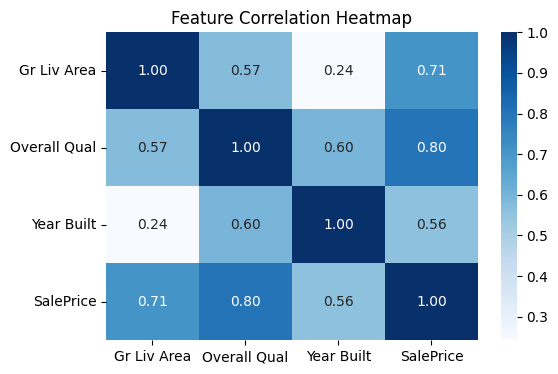

In [ ]:
# If model_df isn't in memory, try to load the saved modeling CSV
if 'model_df' not in globals():
    model_path = Path.cwd().parent / 'data' / 'AmesHousing_model.csv'
    if model_path.exists():
        print(f"'model_df' not found in memory — loading modeling CSV from {model_path}")
        model_df = pd.read_csv(model_path)
    else:
        raise NameError("'model_df' not defined and 'data/AmesHousing_model.csv' not found. Run the modeling cell or create the CSV first.")

# Compute correlation
corr = model_df.corr()
print("Correlation matrix:\n", corr)

# Show correlations with SalePrice specifically
print("\nCorrelations with SalePrice:")
print(corr['SalePrice'].sort_values(ascending=False))

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

**Correlation analysis:** the printed correlation matrix and heatmap above show how `GrLivArea`, `OverallQual`, and `YearBuilt` relate to `SalePrice`.
- **Overall Quality (0.80)** has the strongest positive relationship with SalePrice, meaning homes with better construction and materials tend to sell for significantly higher prices. 
- **Gr Liv Area (0.71)** is also strongly correlated, indicating that larger homes generally cost more.
- **Year Built (0.56)** shows a moderate relationship, suggesting that newer homes are valued higher.

These results confirm that all three selected features are relevant and appropriate for our regression model.

## b. Build the linear regression model

Regression coefficients (Normal Equation):
  Intercept: -1049260.808041
  Gr Liv Area: 63.102103
  Overall Qual: 26011.043709
  Year Built: 495.541590

Normal Equation error metrics:
  MSE: 1568202535.0003
  RMSE: 39600.5371
  MAE: 27310.7452
  R^2: 0.7542

scikit-learn LinearRegression coefficients:
  Intercept: -1049260.808041
  Gr Liv Area: 63.102103
  Overall Qual: 26011.043709
  Year Built: 495.541590

scikit-learn error metrics:
  MSE: 1568202535.0003
  RMSE: 39600.5371
  MAE: 27310.7452
  R^2: 0.7542

Coefficient comparison (Normal Eq. vs sklearn):
  Intercept: -1049260.808041  vs  -1049260.808041
  Gr Liv Area: 63.102103  vs  63.102103
  Overall Qual: 26011.043709  vs  26011.043709
  Year Built: 495.541590  vs  495.541590
Saved predictions to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing_predictions.csv


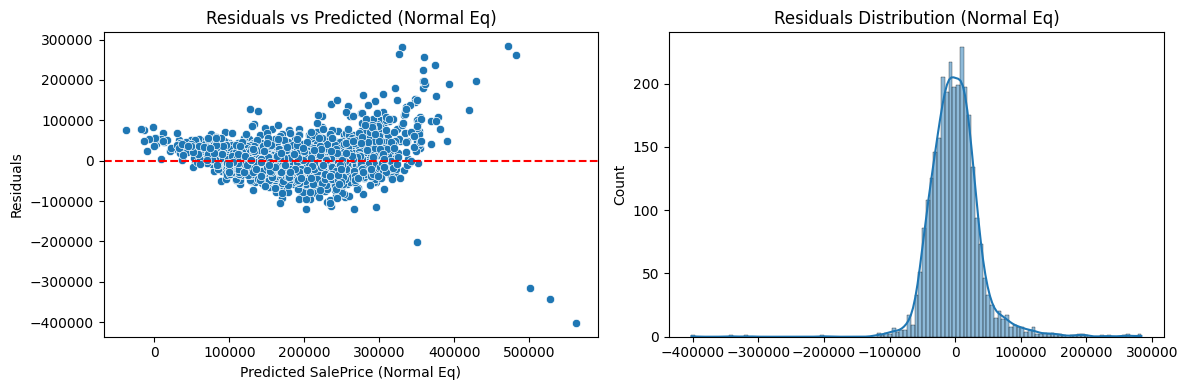

In [20]:
# sklearn imports for comparison
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load or use existing modeling dataframe
if 'model_df' not in globals():
    model_path = Path.cwd().parent / 'data' / 'AmesHousing_model.csv'
    if model_path.exists():
        print(f"'model_df' not found in memory — loading modeling CSV from {model_path}")
        model_df = pd.read_csv(model_path)
    else:
        raise NameError("'model_df' not defined and 'data/AmesHousing_model.csv' not found. Run the modeling cell or create the CSV first.")

# Features and target
features = ['Gr Liv Area', 'Overall Qual', 'Year Built']
target = 'SalePrice'

# Build predictor matrix X and target vector y
X = model_df[features].astype(float).values
y = model_df[target].astype(float).values.reshape(-1,1)

# Add intercept column to design matrix
ones = np.ones((X.shape[0], 1))
X_design = np.hstack([ones, X])

# Compute coefficients using the Normal Equation (use pseudo-inverse for stability)
theta = np.linalg.pinv(X_design) @ y

# Show coefficients
coef_names = ['Intercept'] + features
print('Regression coefficients (Normal Equation):')
for name, val in zip(coef_names, theta.flatten()):
    print(f'  {name}: {val:.6f}')

# Make predictions and compute residuals (Normal Equation)
y_pred = X_design @ theta
residuals = (y - y_pred).flatten()

# Error metrics (Normal Equation)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res/ss_tot
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(residuals))
print('\nNormal Equation error metrics:')
print(f'  MSE: {mse:.4f}')
print(f'  RMSE: {rmse:.4f}')
print(f'  MAE: {mae:.4f}')
print(f'  R^2: {r2:.4f}')

# sklearn LinearRegression comparison
lr = LinearRegression(fit_intercept=True)
lr.fit(X, y.ravel())
y_pred_sk = lr.predict(X).reshape(-1,1)

# sklearn coefficients (note sklearn stores coef_ for features only)
print('\nscikit-learn LinearRegression coefficients:')
print(f'  Intercept: {lr.intercept_:.6f}')
for name, val in zip(features, lr.coef_.flatten()):
    print(f'  {name}: {val:.6f}')

# sklearn metrics
mse_sk = mean_squared_error(y, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y, y_pred_sk)
r2_sk = r2_score(y, y_pred_sk)
print('\nscikit-learn error metrics:')
print(f'  MSE: {mse_sk:.4f}')
print(f'  RMSE: {rmse_sk:.4f}')
print(f'  MAE: {mae_sk:.4f}')
print(f'  R^2: {r2_sk:.4f}')

# Compare coefficients side-by-side
print('\nCoefficient comparison (Normal Eq. vs sklearn):')
print(f"  Intercept: {theta.flatten()[0]:.6f}  vs  {lr.intercept_:.6f}")
for i, name in enumerate(features):
    print(f"  {name}: {theta.flatten()[i+1]:.6f}  vs  {lr.coef_.flatten()[i]:.6f}")

# Build results DataFrame and save predictions
results = model_df.reset_index(drop=True).copy()
results['Pred_NormalEq'] = y_pred.flatten()
results['Pred_sklearn'] = y_pred_sk.flatten()
results['Residual_NormalEq'] = residuals
# Save to CSV
predict_path = Path.cwd().parent / 'data' / 'AmesHousing_predictions.csv'
predict_path.parent.mkdir(parents=True, exist_ok=True)
results.to_csv(predict_path, index=False)
print(f"Saved predictions to: {predict_path}")

# Plot residual diagnostics for Normal Equation
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(x=y_pred.flatten(), y=residuals, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted SalePrice (Normal Eq)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted (Normal Eq)')
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Residuals Distribution (Normal Eq)')
plt.tight_layout()
plt.show()

The strongest predictor is Overall Quality, where each one-point increase raises price by approximately $26,000. Living area also has a positive effect, adding roughly $63 per square foot. Newer homes are slightly more valuable, increasing price by about $495 per year.

Model accuracy metrics show an RMSE of around $39,600 and an MAE of $27,310, which is reasonable for a simple linear model with only three features. The residual plot indicates that errors are centered around zero but widen toward higher-priced homes, suggesting the model underestimates more expensive properties. The residual distribution is roughly bell-shaped, indicating no major violations of regression assumptions.

## c. Mathematical Explanation of Least Squares

To estimate the linear relationship between predictors and SalePrice, we use the **least-squares approach**. We assume a linear model of the form:

$$\hat{y} = X\beta$$

where:
- $X$ is the design matrix (including an intercept column)
- $y$ is the vector of observed prices
- $\beta$ is the parameter vector to be estimated

### Objective Function

Least squares chooses $\beta$ to minimize the sum of squared residuals:

$$S(\beta) = (y - X\beta)^T (y - X\beta)$$

### Deriving the Normal Equation

Differentiating $S(\beta)$ with respect to $\beta$ and setting the gradient equal to zero:

$$\frac{\partial S}{\partial \beta} = -2X^T (y - X\beta) = 0$$

Rearranging:

$$X^T X\beta = X^T y$$

This is the **Normal Equation**.

### Closed-Form Solution

Assuming $X^T X$ is invertible, the least-squares estimator is:

$$\beta = (X^T X)^{-1} X^T y$$

This solution guarantees that $\beta$ minimizes the squared prediction error and provides the **best linear unbiased estimate** under standard regression assumptions (Gauss-Markov theorem).

## d. Extended Model with Five Features

Extended modeling dataset shape: (2930, 6)

Extended Model Coefficients (Normal Equation):
  Intercept: -1075805.700335
  Gr Liv Area: 80.163862
  Overall Qual: 23932.344643
  Bedroom AbvGr: -11350.904556
  Full Bath: -6612.984921
  Year Built: 524.143752

Extended Model Error Metrics:
  MSE: 1497329709.7711
  RMSE: 38695.3448
  MAE: 26346.5586
  R^2: 0.7653

Extended Model - sklearn LinearRegression:
  Intercept: -1075805.700335
  Gr Liv Area: 80.163862
  Overall Qual: 23932.344643
  Bedroom AbvGr: -11350.904556
  Full Bath: -6612.984921
  Year Built: 524.143752

  R^2: 0.7653
  RMSE: 38695.3448
  MAE: 26346.5586

Saved extended model predictions to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing_predictions_extended.csv


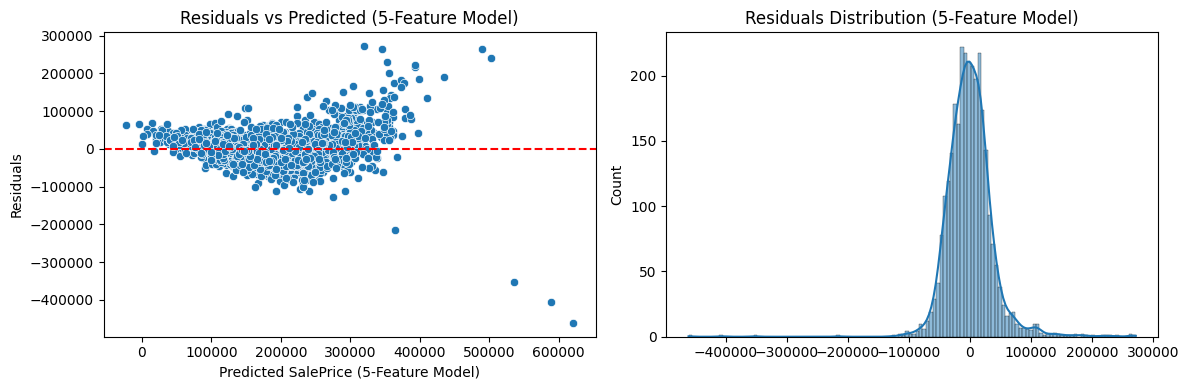

In [21]:
# Load or use existing dataframe for extended model
if 'df' not in globals():
    cleaned_path = Path.cwd().parent / 'data' / 'AmesHousing_cleaned.csv'
    if cleaned_path.exists():
        print(f"Loading cleaned CSV for extended model...")
        df = pd.read_csv(cleaned_path)
    else:
        raise NameError("Cleaned CSV not found. Run data loading/cleaning cells first.")

# Extended features (5 features instead of 3)
features_ext = [
    'Gr Liv Area',
    'Overall Qual',
    'Bedroom AbvGr',
    'Full Bath',
    'Year Built'
]
target = 'SalePrice'

cols_ext = features_ext + [target]

# Verify all columns exist
missing = [c for c in cols_ext if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns for extended model: {missing}")

# Create extended modeling dataset
model_df_ext = df[cols_ext].copy()
model_df_ext = model_df_ext.dropna()
print(f"Extended modeling dataset shape: {model_df_ext.shape}")

# Build X and y for extended model
X_ext = model_df_ext[features_ext].astype(float).values
y_ext = model_df_ext[target].astype(float).values.reshape(-1,1)

# Add intercept column
ones_ext = np.ones((X_ext.shape[0], 1))
X_design_ext = np.hstack([ones_ext, X_ext])

# Normal Equation coefficients
theta_ext = np.linalg.pinv(X_design_ext) @ y_ext

# Print coefficients
coef_names_ext = ['Intercept'] + features_ext
print('\nExtended Model Coefficients (Normal Equation):')
for name, val in zip(coef_names_ext, theta_ext.flatten()):
    print(f'  {name}: {val:.6f}')

# Predictions and residuals
y_pred_ext = X_design_ext @ theta_ext
residuals_ext = (y_ext - y_pred_ext).flatten()

# Error metrics
ss_res_ext = np.sum(residuals_ext**2)
ss_tot_ext = np.sum((y_ext - y_ext.mean())**2)
r2_ext = 1 - ss_res_ext/ss_tot_ext
mse_ext = np.mean(residuals_ext**2)
rmse_ext = np.sqrt(mse_ext)
mae_ext = np.mean(np.abs(residuals_ext))
print('\nExtended Model Error Metrics:')
print(f'  MSE: {mse_ext:.4f}')
print(f'  RMSE: {rmse_ext:.4f}')
print(f'  MAE: {mae_ext:.4f}')
print(f'  R^2: {r2_ext:.4f}')

# Compare with sklearn
lr_ext = LinearRegression(fit_intercept=True)
lr_ext.fit(X_ext, y_ext.ravel())
y_pred_sk_ext = lr_ext.predict(X_ext).reshape(-1,1)

print('\nExtended Model - sklearn LinearRegression:')
print(f'  Intercept: {lr_ext.intercept_:.6f}')
for name, val in zip(features_ext, lr_ext.coef_.flatten()):
    print(f'  {name}: {val:.6f}')

r2_sk_ext = r2_score(y_ext, y_pred_sk_ext)
rmse_sk_ext = np.sqrt(mean_squared_error(y_ext, y_pred_sk_ext))
mae_sk_ext = mean_absolute_error(y_ext, y_pred_sk_ext)
print(f'\n  R^2: {r2_sk_ext:.4f}')
print(f'  RMSE: {rmse_sk_ext:.4f}')
print(f'  MAE: {mae_sk_ext:.4f}')

# Build results DataFrame with extended predictions
results_ext = model_df_ext.reset_index(drop=True).copy()
results_ext['Pred_NormalEq_5feat'] = y_pred_ext.flatten()
results_ext['Pred_sklearn_5feat'] = y_pred_sk_ext.flatten()
results_ext['Residual_NormalEq_5feat'] = residuals_ext

# Save extended predictions
predict_path_ext = Path.cwd().parent / 'data' / 'AmesHousing_predictions_extended.csv'
predict_path_ext.parent.mkdir(parents=True, exist_ok=True)
results_ext.to_csv(predict_path_ext, index=False)
print(f"\nSaved extended model predictions to: {predict_path_ext}")

# Plot residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(x=y_pred_ext.flatten(), y=residuals_ext, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted SalePrice (5-Feature Model)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted (5-Feature Model)')
sns.histplot(residuals_ext, kde=True, ax=axes[1])
axes[1].set_title('Residuals Distribution (5-Feature Model)')
plt.tight_layout()
plt.show()

In [25]:
# Helper function to compute predicted price with your extended model
def predict_price(area, qual, bed, bath, year):
    X = np.array([1, area, qual, bed, bath, year])
    return float(X @ theta_ext)

print("=== 5-Feature Model Test Scenarios ===\n")

tests = [
    # 1–2 Bathroom-only changes
    ("Test 1: 2 baths",                1800, 6, 3, 2, 2000),
    ("Test 2: 3 baths (only bath +1)", 1800, 6, 3, 3, 2000),

    # 3–4 Bedroom-only changes
    ("Test 3: 3 bedrooms",             1800, 7, 3, 2, 2005),
    ("Test 4: 4 bedrooms",             1800, 7, 4, 2, 2005),

    # 5–6 Bath + Area increase
    ("Test 5: baseline",               1800, 7, 3, 2, 2010),
    ("Test 6: +200 sqft, +1 bath",     2000, 7, 3, 3, 2010),

    # 7–8 Bedroom + Area increase
    ("Test 7: 2 beds baseline",        1500, 6, 2, 1, 1995),
    ("Test 8: +1 bed +300 sqft",       1800, 6, 3, 1, 1995),

    # 9–10 Quality + Bath changes
    ("Test 9: qual=5, 2 baths",        2200, 5, 3, 2, 1990),
    ("Test 10: qual=8, 3 baths",       2200, 8, 3, 3, 1990),

    # 11–12 Luxury home bathroom change
    ("Test 11: luxury, 3 baths",       3500, 9, 4, 3, 2018),
    ("Test 12: luxury, 4 baths",       3500, 9, 4, 4, 2018),

    # 13–14 Small home bath change
    ("Test 13: small home 1 bath",     1000, 5, 2, 1, 1980),
    ("Test 14: small home 2 baths",    1000, 5, 2, 2, 1980),

    # 15 Old vs new
    ("Test 15: built 1980",            2000, 7, 3, 2, 1980),
    ("Test 16: built 2010",            2000, 7, 3, 2, 2010),
]

# Run all tests
for label, area, qual, bed, bath, year in tests:
    price = predict_price(area, qual, bed, bath, year)
    print(f"{label:35s} → Predicted Price: ${price:,.2f}")

=== 5-Feature Model Test Scenarios ===

Test 1: 2 baths                     → Predicted Price: $213,092.14
Test 2: 3 baths (only bath +1)      → Predicted Price: $206,479.15
Test 3: 3 bedrooms                  → Predicted Price: $239,645.20
Test 4: 4 bedrooms                  → Predicted Price: $228,294.30
Test 5: baseline                    → Predicted Price: $242,265.92
Test 6: +200 sqft, +1 bath          → Predicted Price: $251,685.71
Test 7: 2 beds baseline             → Predicted Price: $204,386.15
Test 8: +1 bed +300 sqft            → Predicted Price: $217,084.41
Test 9: qual=5, 2 baths             → Predicted Price: $215,983.90
Test 10: qual=8, 3 baths            → Predicted Price: $281,167.95
Test 11: luxury, 3 baths            → Predicted Price: $412,638.44
Test 12: luxury, 4 baths            → Predicted Price: $406,025.45
Test 13: small home 1 bath          → Predicted Price: $132,509.72
Test 14: small home 2 baths         → Predicted Price: $125,896.73
Test 15: built 1980   

C:\Users\phaml\AppData\Local\Temp\ipykernel_34468\3838066550.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(X @ theta_ext)
